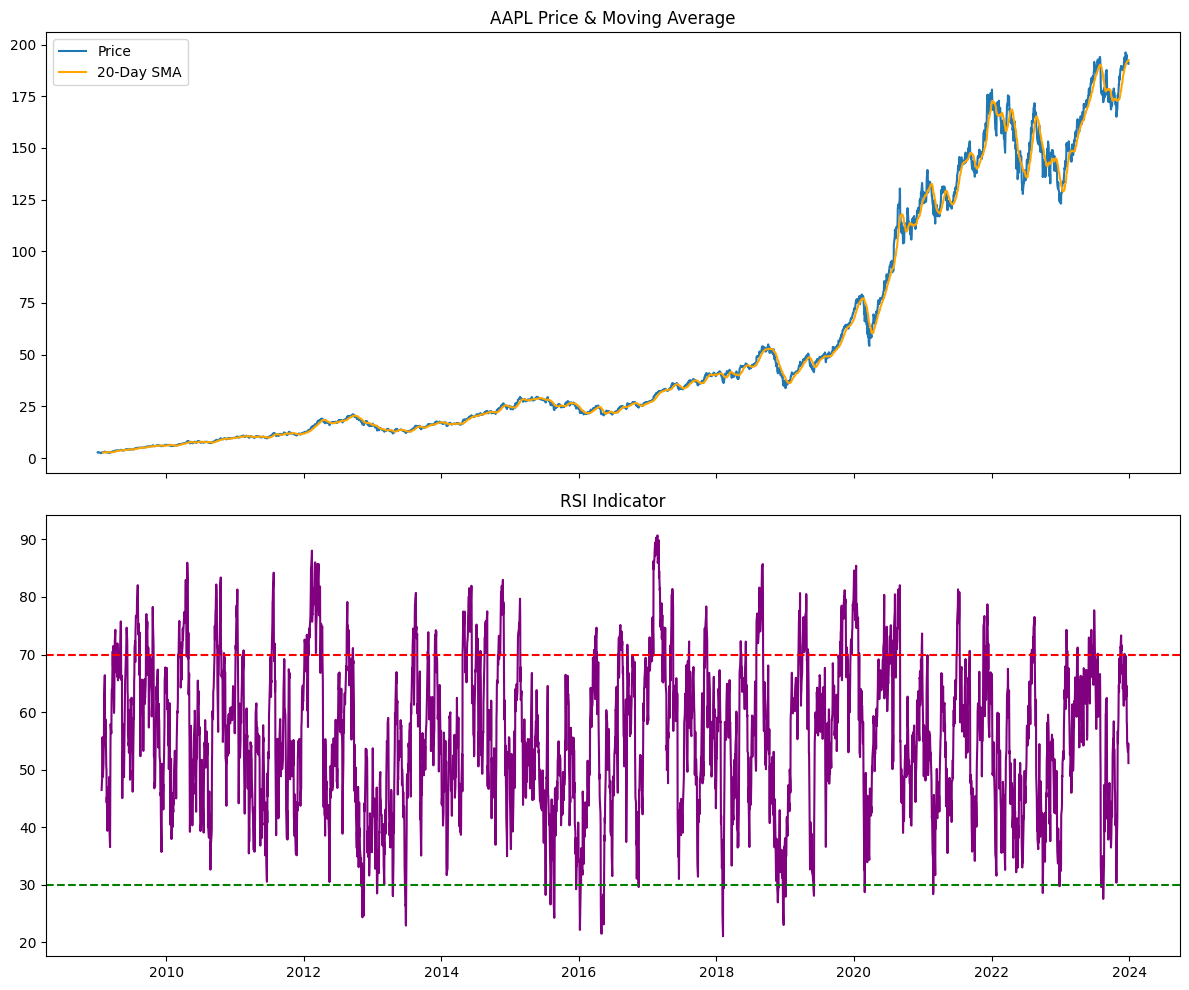

In [1]:
import pandas as pd
import talib
import matplotlib.pyplot as plt

# 1. Load AAPL Data
stock_df = pd.read_csv('../data/raw/AAPL.csv')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df.set_index('Date', inplace=True)
stock_df.sort_index(inplace=True)

# 2. TA-Lib Indicators (Project Requirement)
stock_df['SMA_20'] = talib.SMA(stock_df['Close'], timeperiod=20)
stock_df['RSI'] = talib.RSI(stock_df['Close'], timeperiod=14)
macd, macdsignal, _ = talib.MACD(stock_df['Close'])
stock_df['MACD'] = macd

# 3. Financial Metrics (Calculate daily returns)
# Daily returns (percentage change)
stock_df['Returns'] = stock_df['Close'].pct_change()

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax1.plot(stock_df['Close'], label='Price')
ax1.plot(stock_df['SMA_20'], label='20-Day SMA', color='orange')
ax1.set_title('AAPL Price & Moving Average')
ax1.legend()

ax2.plot(stock_df['RSI'], color='purple', label='RSI')
ax2.axhline(70, color='red', linestyle='--') # Overbought
ax2.axhline(30, color='green', linestyle='--') # Oversold
ax2.set_title('RSI Indicator')

plt.tight_layout()
plt.show()


In [4]:
import pandas as pd
import numpy as np
import talib

# We already have SMA_20 and RSI. Let's add the rest.

# 1. Bollinger Bands (Trend Volatility)
upper, middle, lower = talib.BBANDS(stock_df['Close'], timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
stock_df['BB_Upper'] = upper
stock_df['BB_Middle'] = middle
stock_df['BB_Lower'] = lower

# 2. Average True Range (ATR - Measure of Volatility)
stock_df['ATR'] = talib.ATR(stock_df['High'], stock_df['Low'], stock_df['Close'], timeperiod=14)

# 3. Logarithmic Returns (more accurate for financial modeling)
stock_df['Log_Returns'] = np.log(stock_df['Close'] / stock_df['Close'].shift(1))

print("Quantitative Metrics Computed Successfully.")
print(stock_df[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'ATR']].tail())


Quantitative Metrics Computed Successfully.
                 Close      SMA_20        RSI    BB_Upper       ATR
Date                                                               
2023-12-22  191.788757  191.856618  54.672784  197.478146  2.766028
2023-12-26  191.243912  192.018094  53.090049  197.367843  2.643460
2023-12-27  191.342972  192.154308  53.354446  197.285152  2.625174
2023-12-28  191.768951  192.362839  54.540999  197.056446  2.544510
2023-12-29  190.728775  192.490633  51.121347  196.848102  2.551689


In [5]:
# Create the directory if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Save the data
stock_df.to_csv('../data/processed/AAPL_with_indicators.csv')
print("Processed stock data saved to data/processed/")

Processed stock data saved to data/processed/
